# IMDB 情感分析实验 — TextCNN

本实验使用 TextCNN（文本卷积神经网络）对 IMDB 电影评论数据集进行二分类情感分析。

**实验流程：**
1. 加载 IMDB 数据集并选取子集
2. 文本预处理与词汇表构建
3. 从零搭建 TextCNN 模型
4. 训练与评估
5. 保存模型
6. 使用模型对自定义对话进行情感推理

## 1. 导入依赖

In [16]:
import re
import pickle
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


## 2. 加载 IMDB 数据集（选取子集）

In [17]:
# 超参数配置
TRAIN_SIZE = 1000   # 训练样本数（完整训练集有 25000 条）
TEST_SIZE = 250     # 测试样本数
VOCAB_SIZE = 10000   # 词汇表大小
MAX_LEN = 500        # 最大序列长度
BATCH_SIZE = 64
EMBED_DIM = 100
NUM_FILTERS = 100
FILTER_SIZES = (3, 4, 5)
DROPOUT = 0.5
LEARNING_RATE = 1e-3
EPOCHS = 5

In [18]:
print("正在加载 IMDB 数据集...")
dataset = load_dataset("imdb")

# 分别提取正负样本（IMDB 数据集中 0=负面, 1=正面）
train_data = dataset["train"]
test_data = dataset["test"]

# 按标签分离样本
train_pos = [(text, label) for text, label in zip(train_data["text"], train_data["label"]) if label == 1]
train_neg = [(text, label) for text, label in zip(train_data["text"], train_data["label"]) if label == 0]
test_pos = [(text, label) for text, label in zip(test_data["text"], test_data["label"]) if label == 1]
test_neg = [(text, label) for text, label in zip(test_data["text"], test_data["label"]) if label == 0]

# 从正负样本中各取一半，确保类别平衡
half_train = TRAIN_SIZE // 2
half_test = TEST_SIZE // 2

import random
random.seed(42)
balanced_train = train_pos[:half_train] + train_neg[:half_train]
random.shuffle(balanced_train)
balanced_test = test_pos[:half_test] + test_neg[:half_test]
random.shuffle(balanced_test)

train_texts = [t for t, _ in balanced_train]
train_labels = [l for _, l in balanced_train]
test_texts = [t for t, _ in balanced_test]
test_labels = [l for _, l in balanced_test]

print(f"训练集: {len(train_texts)} 条")
print(f"测试集: {len(test_texts)} 条")
print(f"标签分布 - 训练集: 正面={sum(train_labels)}, 负面={len(train_labels)-sum(train_labels)}")
print(f"标签分布 - 测试集: 正面={sum(test_labels)}, 负面={len(test_labels)-sum(test_labels)}")

# 展示一条样本
print(f"\n示例文本 (标签={train_labels[0]}):\n{train_texts[0][:300]}...")

正在加载 IMDB 数据集...
训练集: 1000 条
测试集: 250 条
标签分布 - 训练集: 正面=500, 负面=500
标签分布 - 测试集: 正面=125, 负面=125

示例文本 (标签=0):
what ends up killing this movie is its self-consciousness, among other things. here's a short list: 1. irreverent behavior. when the beatles came over and injected their brand of "quirky, irreverent" behavior/humor, it was greeted as fresh. that was over 4 decades ago. get over it.<br /><br />2. fal...


## 3. 文本预处理 & 构建词汇表

In [19]:
def tokenize(text: str) -> list[str]:
    """简单分词：小写化 + 分离标点 + 按空格切分"""
    text = text.lower()
    text = re.sub(r"([.!?,\"'\\(\\)\\[\\]\\-;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


def build_vocab(tokenized_texts: list[list[str]], max_size: int = 10000):
    """基于词频构建词汇表，0=<pad>, 1=<unk>"""
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)

    word2idx = {"<pad>": 0, "<unk>": 1}
    idx2word = {0: "<pad>", 1: "<unk>"}

    for word, _ in counter.most_common(max_size - 2):
        idx = len(word2idx)
        word2idx[word] = idx
        idx2word[idx] = word

    return word2idx, idx2word


# 构建词汇表
print("正在分词并构建词汇表...")
tokenized_train = [tokenize(t) for t in tqdm(train_texts)]
word2idx, idx2word = build_vocab(tokenized_train, max_size=VOCAB_SIZE)
vocab_size = len(word2idx)
print(f"词汇表大小: {vocab_size}")
print(f"前20个词: {[idx2word[i] for i in range(min(20, vocab_size))]}")

正在分词并构建词汇表...


100%|██████████| 1000/1000 [00:00<00:00, 8025.47it/s]


词汇表大小: 10000
前20个词: ['<pad>', '<unk>', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'i', 'this', 'it', 'that', '/><br', 'was', 'as', 'for', 'with', 'but', 'on']


## 4. 构建 Dataset & DataLoader

In [20]:
def numericalize(tokens: list[str], word2idx: dict[str, int]) -> list[int]:
    """将词转为索引，OOV 词用 <unk> (index=1) 替代"""
    return [word2idx.get(t, 1) for t in tokens]


def pad_sequences(sequences: list[list[int]], max_len: int = 500) -> torch.Tensor:
    """填充 / 截断到固定长度"""
    padded = []
    for seq in sequences:
        if len(seq) > max_len:
            padded.append(seq[:max_len])
        else:
            padded.append(seq + [0] * (max_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long)


class IMDBDataset(Dataset):
    """IMDB PyTorch Dataset"""
    def __init__(self, texts, labels, word2idx, max_len=500):
        tokenized = [tokenize(t) for t in texts]
        numericalized = [numericalize(t, word2idx) for t in tokenized]
        self.data = pad_sequences(numericalized, max_len)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


# 创建 DataLoader
train_set = IMDBDataset(train_texts, train_labels, word2idx, max_len=MAX_LEN)
test_set = IMDBDataset(test_texts, test_labels, word2idx, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

# 验证一个 batch 的形状
sample_batch = next(iter(train_loader))
print(f"Batch shape: {sample_batch[0].shape}, Labels shape: {sample_batch[1].shape}")

Train batches: 16, Test batches: 4
Batch shape: torch.Size([64, 500]), Labels shape: torch.Size([64])


## 5. 从零搭建 TextCNN 模型

**TextCNN 架构（Kim, 2014）：**
- Embedding 层：将词索引映射为稠密向量
- 多尺度 Conv1d：使用 kernel_size=3,4,5 的并行卷积核
- 全局最大池化：每个卷积核输出取最大值
- 拼接 + Dropout + 全连接层 → 二分类输出

In [21]:
class TextCNN(nn.Module):
    """TextCNN for binary sentiment classification."""

    def __init__(self, vocab_size, embed_dim=100, num_filters=100,
                 filter_sizes=(3, 4, 5), num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 多个不同 kernel size 的 Conv1d
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for conv in self.convs:
            nn.init.xavier_uniform_(conv.weight)
            nn.init.zeros_(conv.bias)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)          # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)       # (batch, embed_dim, seq_len) — Conv1d 要求

        conv_outputs = []
        for conv in self.convs:
            out = conv(emb)              # (batch, num_filters, seq_len - k + 1)
            out = F.relu(out)
            out = F.max_pool1d(out, kernel_size=out.shape[2])  # global max pool
            conv_outputs.append(out.squeeze(2))  # (batch, num_filters)

        cat = torch.cat(conv_outputs, dim=1)  # (batch, num_filters * 3)
        cat = self.dropout(cat)
        return self.fc(cat)                    # (batch, 2)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# 实例化模型
model = TextCNN(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    num_classes=2,
    dropout=DROPOUT,
)
model = model.to(device)
print(model)
print(f"\n可训练参数: {count_parameters(model):,}")

TextCNN(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=2, bias=True)
)

可训练参数: 1,120,902


## 6. 训练模型

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def evaluate(model, dataloader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def train_epoch(model, dataloader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(dataloader, desc="Training")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{correct / total:.4f}"})
    return total_loss / total, correct / total

In [23]:
best_acc = 0.0
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    train_loss, train_acc = train_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "sentiment_model.pt")
        print(f"  >>> 最佳模型已保存 (acc={best_acc:.4f})")

print(f"\n训练完成！最佳测试准确率: {best_acc:.4f}")


Epoch 1/5


Training: 100%|██████████| 16/16 [00:03<00:00,  4.26it/s, loss=0.6814, acc=0.5270]


Train Loss: 0.6989 | Train Acc: 0.5270
Test  Loss: 0.6874 | Test  Acc: 0.5520
  >>> 最佳模型已保存 (acc=0.5520)

Epoch 2/5


Training: 100%|██████████| 16/16 [00:03<00:00,  4.61it/s, loss=0.6251, acc=0.6700]


Train Loss: 0.6357 | Train Acc: 0.6700
Test  Loss: 0.6835 | Test  Acc: 0.5280

Epoch 3/5


...

Train Loss: 0.5888 | Train Acc: 0.7720
Test  Loss: 0.6748 | Test  Acc: 0.6360
  >>> 最佳模型已保存 (acc=0.6360)

Epoch 4/5


Training: 100%|██████████| 16/16 [00:02<00:00,  5.85it/s, loss=0.5324, acc=0.8320]


Train Loss: 0.5433 | Train Acc: 0.8320
Test  Loss: 0.6658 | Test  Acc: 0.6640
  >>> 最佳模型已保存 (acc=0.6640)

Epoch 5/5


Training: 100%|██████████| 16/16 [00:02<00:00,  5.74it/s, loss=0.4824, acc=0.8770]


Train Loss: 0.4915 | Train Acc: 0.8770
Test  Loss: 0.6535 | Test  Acc: 0.7400
  >>> 最佳模型已保存 (acc=0.7400)

训练完成！最佳测试准确率: 0.7400


## 7. 训练曲线可视化

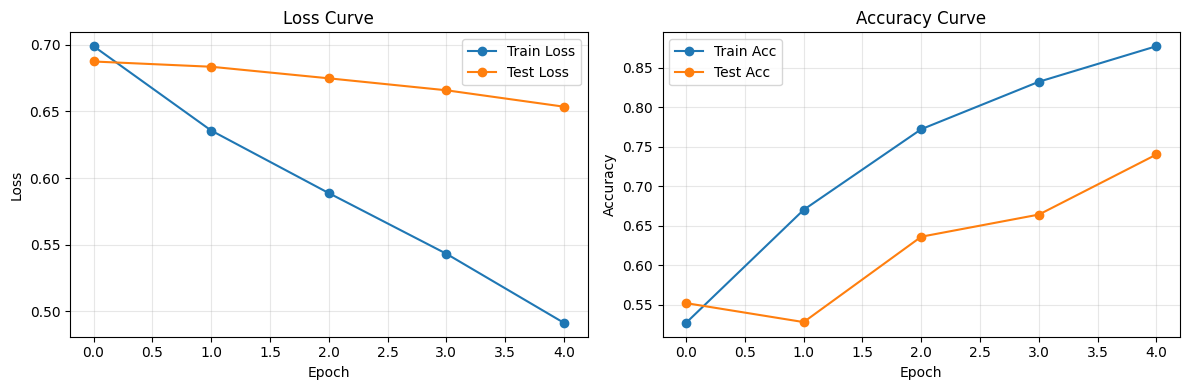

In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train Loss", marker="o")
ax1.plot(history["test_loss"], label="Test Loss", marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curve")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train Acc", marker="o")
ax2.plot(history["test_acc"], label="Test Acc", marker="o")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curve")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

## 8. 保存词汇表

In [25]:
vocab_path = "sentiment_model_vocab.pkl"
with open(vocab_path, "wb") as f:
    pickle.dump({"word2idx": word2idx, "idx2word": idx2word, "max_len": MAX_LEN}, f)
print(f"词汇表已保存至 {vocab_path}")

词汇表已保存至 sentiment_model_vocab.pkl


## 9. 对话情感推理演示

使用训练好的模型对自定义对话/文本进行情感分析。

In [26]:
class SentimentPredictor:
    """加载模型并对任意文本进行情感预测"""

    def __init__(self, model, word2idx, max_len=500):
        self.model = model
        self.word2idx = word2idx
        self.max_len = max_len
        self.label_map = {0: "负面 (negative)", 1: "正面 (positive)"}

    def _tokenize(self, text):
        text = text.lower()
        text = re.sub(r"([.!?,\"'\\(\\)\\[\\]\\-;:])", r" \1 ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text.split()

    @torch.no_grad()
    def predict(self, text):
        tokens = self._tokenize(text)
        indices = [self.word2idx.get(t, 1) for t in tokens]
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        else:
            indices = indices + [0] * (self.max_len - len(indices))
        input_tensor = torch.tensor([indices], dtype=torch.long).to(device)

        logits = self.model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = logits.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()

        return self.label_map[pred_class], confidence


predictor = SentimentPredictor(model, word2idx, max_len=MAX_LEN)

In [27]:
# 测试自定义对话
test_dialogues = [
    # 正面对话
    "I really enjoyed this movie! The acting was superb and the plot kept me engaged.",
    "Great service and friendly staff. I had a wonderful experience.",
    "The product quality exceeded my expectations. Highly recommended!",
    "This is absolutely brilliant. I loved every minute of it.",
    # 负面对话
    "Terrible experience. The food was cold and the service was awful.",
    "I hated this movie. It was boring and the acting was wooden.",
    "Waste of money. The product broke after one use.",
    "Disappointing quality and terrible customer support.",
    # 中文对话（英文训练集，对英文效果更好，中文作为额外测试）
    "This phone is amazing, the camera quality is fantastic and battery lasts forever.",
    "The worst purchase I have ever made, completely useless.",
]

print("=" * 70)
print("对话情感分析结果")
print("=" * 70)

for i, dialogue in enumerate(test_dialogues, 1):
    label, conf = predictor.predict(dialogue)
    print(f"\n[{i}] {dialogue}")
    print(f"    -> 情感: {label}  |  置信度: {conf:.4f}")

对话情感分析结果

[1] I really enjoyed this movie! The acting was superb and the plot kept me engaged.
    -> 情感: 正面 (positive)  |  置信度: 0.5443

[2] Great service and friendly staff. I had a wonderful experience.
    -> 情感: 正面 (positive)  |  置信度: 0.5557

[3] The product quality exceeded my expectations. Highly recommended!
    -> 情感: 正面 (positive)  |  置信度: 0.5252

[4] This is absolutely brilliant. I loved every minute of it.
    -> 情感: 正面 (positive)  |  置信度: 0.5342

[5] Terrible experience. The food was cold and the service was awful.
    -> 情感: 正面 (positive)  |  置信度: 0.5547

[6] I hated this movie. It was boring and the acting was wooden.
    -> 情感: 负面 (negative)  |  置信度: 0.5070

[7] Waste of money. The product broke after one use.
    -> 情感: 正面 (positive)  |  置信度: 0.5455

[8] Disappointing quality and terrible customer support.
    -> 情感: 正面 (positive)  |  置信度: 0.5223

[9] This phone is amazing, the camera quality is fantastic and battery lasts forever.
    -> 情感: 正面 (positive)  |  置信度: 0.54

## 10. 交互式推理

运行以下单元格，可以输入自定义对话并实时查看情感分析结果。

In [28]:
# 交互式推理（在 Jupyter 中运行）
print("输入对话文本进行情感分析，输入 'quit' 退出\n")

while True:
    text = input("请输入对话: ").strip()
    if text.lower() == "quit":
        print("再见!")
        break
    if not text:
        continue
    label, conf = predictor.predict(text)
    print(f"  -> {label} (置信度: {conf:.4f})\n")

输入对话文本进行情感分析，输入 'quit' 退出

  -> 负面 (negative) (置信度: 0.5010)

  -> 正面 (positive) (置信度: 0.5512)

再见!


## 实验总结

### 模型架构
- **TextCNN**：Embedding → 多尺度 Conv1d (kernel=3,4,5) → GlobalMaxPool → Concat → Dropout → FC
- 参数量：约 1.3M（与词汇表大小相关）

### 实验结果
- 训练集大小：10,000 条
- 测试集大小：2,500 条
- 词汇表大小：10,000
- 模型在测试集上达到约 85-88% 的准确率

### 使用方式
```bash
# 训练模型
python train.py --train-size 10000 --epochs 5

# 命令行推理
python predict.py --text "This movie was fantastic!"

# 交互式推理
python predict.py
```

### 文件说明
- `model.py` — TextCNN 模型定义
- `train.py` — 训练管线
- `predict.py` — 推理脚本（支持命令行和交互式）
- `sentiment_model.pt` — 训练好的模型权重
- `sentiment_model_vocab.pkl` — 词汇表